# Proyek 1 Machine Learning Terapan: Predictive Analysis

- **Nama:** Fadhilah Nurrahmayanti
- **Email:** a117xbm150@devacademy.id
- **ID Dicoding:** dilaafn


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

## Data Loading

In [2]:
df = pd.read_csv('Data.csv')
df

,Entity,Year,Maize Production (tonnes),Rice Production ( tonnes),Yams Production (tonnes),Wheat Production (tonnes),Tomatoes Production (tonnes),Tea Production ( tonnes ),Sweet potatoes Production (tonnes),Sunflower seed Production (tonnes),...,Oranges Production (tonnes),"Peas, dry Production ( tonnes)",Palm oil Production (tonnes),Grapes Production (tonnes),"Coffee, green Production ( tonnes)",Cocoa beans Production (tonnes),"Meat, chicken Production (tonnes)",Bananas Production ( tonnes),Avocados Production (tonnes),Apples Production (tonnes)
0,Afghanistan,1961,700000.0,319000.00,7.467702e+06,2279000.00,1873812.000,56315.0,3270871.000,12000.000,...,10100.000,232910.000,1131882.00,2.250000e+05,870970.000,835368.000,5600.00,3139079.000,63439.000,15100.000
1,Afghanistan,1962,700000.0,319000.00,7.420515e+06,2279000.00,2044797.000,61519.0,3562524.000,12800.000,...,10100.000,259412.000,1111006.00,2.250000e+05,883512.000,867170.000,6000.00,3181580.000,65118.000,15100.000
2,Afghanistan,1963,713000.0,319000.00,8.479074e+06,1947000.00,2096077.000,63596.0,3409916.000,12800.000,...,10100.000,251529.000,1145004.00,2.250000e+05,996674.000,922621.000,6160.00,3304256.000,61760.000,15100.000
3,Afghanistan,1964,720000.0,380000.00,9.113779e+06,2230000.00,2388264.000,66604.0,3229336.000,12800.000,...,12400.000,247556.000,1160831.00,2.650000e+05,1162048.000,1190061.000,6400.00,3392527.000,62759.000,18400.000
4,Afghanistan,1965,720000.0,380000.00,1.006791e+07,2282000.00,2559608.000,72418.0,3169104.000,13200.000,...,13700.000,266947.000,1138860.00,2.870000e+05,1075084.000,874245.000,6800.00,3450849.000,66269.000,20400.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11907,Zimbabwe,2017,1532572.0,20502618.00,2.673608e+05,30991516.16,324020.864,83904.6,874.408,4077308.066,...,129055.800,40749.600,661978.98,7.018985e+06,63.200,34945.000,75000.00,1267.200,145042.096,1579154.000
11908,Zimbabwe,2018,1560100.0,31871776.60,2.667498e+05,16884482.98,309316.252,66842.6,1383.792,2107639.306,...,168074.000,21606.400,485223.38,3.415107e+06,68.000,34659.800,80357.14,1016.776,143384.384,907419.000
11909,Zimbabwe,2019,773976.0,3382151.40,4.790022e+05,64989733.20,540128.592,9854.4,298831.560,3320915.400,...,1134136.812,45436.400,361128.20,9.645766e+06,30401.400,20961.132,79790.97,195845.198,525095.272,3117813.560
11910,Zimbabwe,2020,1202347.0,3535631.80,7.437612e+05,43020887.20,5635740.200,276279.0,1727311.800,983256.000,...,72179.400,12023.200,279613.40,1.131937e+07,574723.374,158022.122,8000.00,1523258.600,28946.840,7994169.220


Insight:

- Ada 11912 baris (records atau jumlah pengamatan) dan 24 kolom dalam dataset.

## Exploratory Data Analysis (EDA)

### Variable Description

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11912 entries, 0 to 11911
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Entity                               11912 non-null  object 
 1   Year                                 11912 non-null  int64  
 2   Maize Production (tonnes)            11912 non-null  float64
 3   Rice  Production ( tonnes)           11912 non-null  float64
 4   Yams  Production (tonnes)            11912 non-null  float64
 5   Wheat Production (tonnes)            11912 non-null  float64
 6   Tomatoes Production (tonnes)         11912 non-null  float64
 7   Tea  Production ( tonnes )           11912 non-null  float64
 8   Sweet potatoes  Production (tonnes)  11912 non-null  float64
 9   Sunflower seed  Production (tonnes)  11912 non-null  float64
 10  Sugar cane Production (tonnes)       11912 non-null  float64
 11  Soybeans  Production (tonnes

In [4]:
df.describe()

,Year,Maize Production (tonnes),Rice Production ( tonnes),Yams Production (tonnes),Wheat Production (tonnes),Tomatoes Production (tonnes),Tea Production ( tonnes ),Sweet potatoes Production (tonnes),Sunflower seed Production (tonnes),Sugar cane Production (tonnes),...,Oranges Production (tonnes),"Peas, dry Production ( tonnes)",Palm oil Production (tonnes),Grapes Production (tonnes),"Coffee, green Production ( tonnes)",Cocoa beans Production (tonnes),"Meat, chicken Production (tonnes)",Bananas Production ( tonnes),Avocados Production (tonnes),Apples Production (tonnes)
count,11912.000000,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,...,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04,1.191200e+04
mean,1992.115346,1.926434e+07,2.254542e+07,2.744973e+06,2.365684e+07,3.238661e+06,1.350523e+05,5.021303e+06,1.410297e+06,5.218411e+07,...,2.176532e+06,6.375701e+05,1.502615e+06,3.623623e+06,3.549990e+05,2.191661e+05,1.165719e+06,2.653282e+06,1.564768e+05,3.260419e+06
std,17.606091,7.028022e+07,7.749779e+07,8.787786e+06,6.177899e+07,1.146992e+07,2.544264e+05,2.001692e+07,3.625725e+06,1.527085e+08,...,6.078086e+06,1.527103e+06,6.144476e+06,8.225799e+06,8.785398e+05,5.835509e+05,4.050976e+06,8.178866e+06,4.239785e+05,8.748227e+06
min,1961.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1977.000000,2.379300e+04,3.902475e+04,1.176250e+04,8.892500e+04,1.250000e+04,2.040000e+03,7.082605e+03,1.537675e+04,3.312100e+05,...,1.182728e+04,5.196345e+03,1.384195e+04,6.757700e+04,3.119250e+03,1.092024e+03,3.882640e+03,1.007145e+04,3.681500e+03,4.431650e+04
50%,1993.000000,4.000490e+05,4.543745e+05,1.236055e+05,1.650000e+06,1.291410e+05,2.564550e+04,7.828400e+04,1.481504e+05,3.275770e+06,...,1.469060e+05,4.755700e+04,7.887600e+04,4.680664e+05,3.229550e+04,9.160000e+03,3.659000e+04,1.508370e+05,3.577800e+04,4.222070e+05
75%,2007.000000,4.979875e+06,4.440542e+06,5.721030e+05,1.524149e+07,8.691358e+05,1.192675e+05,7.472216e+05,1.115602e+06,2.507227e+07,...,1.434050e+06,4.269712e+05,4.145059e+05,3.080176e+06,2.126140e+05,1.250475e+05,3.547400e+05,1.187962e+06,1.160314e+05,1.950000e+06
max,2021.000000,1.210235e+09,7.872939e+08,7.871405e+07,7.723055e+08,1.891340e+08,2.524670e+06,1.528620e+08,5.818563e+07,1.958234e+09,...,7.656665e+07,1.663746e+07,7.906779e+07,8.001590e+07,1.079544e+07,5.780850e+06,5.017566e+07,1.249786e+08,8.685672e+06,9.314436e+07


In [5]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nAvailable columns:")
print(df.columns.tolist())

Dataset contains 11912 rows and 24 columns.

Available columns:
['Entity', 'Year', 'Maize Production (tonnes)', 'Rice  Production ( tonnes)', 'Yams  Production (tonnes)', 'Wheat Production (tonnes)', 'Tomatoes Production (tonnes)', 'Tea  Production ( tonnes )', 'Sweet potatoes  Production (tonnes)', 'Sunflower seed  Production (tonnes)', 'Sugar cane Production (tonnes)', 'Soybeans  Production (tonnes)', 'Rye  Production (tonnes)', 'Potatoes  Production (tonnes)', 'Oranges  Production (tonnes)', 'Peas, dry Production ( tonnes)', 'Palm oil  Production (tonnes)', 'Grapes  Production (tonnes)', 'Coffee, green Production ( tonnes)', 'Cocoa beans Production (tonnes)', 'Meat, chicken  Production (tonnes)', 'Bananas  Production ( tonnes)', 'Avocados Production (tonnes)', 'Apples Production (tonnes)']


### Checking Missing Value

In [6]:
df.isnull().sum()

,0
Entity,0
Year,0
Maize Production (tonnes),0
Rice Production ( tonnes),0
Yams Production (tonnes),0
Wheat Production (tonnes),0
Tomatoes Production (tonnes),0
Tea Production ( tonnes ),0
Sweet potatoes Production (tonnes),0
Sunflower seed Production (tonnes),0


In [7]:
print('Total Duplikasi Data:', df.duplicated().sum())

Total Duplikasi Data: 0


### Filter for ASEAN Countries and Selected Commodities

In [8]:
target_countries = ['Indonesia', 'Vietnam', 'Thailand', 'Philippines', 'Malaysia']

selected_columns = [
    'Entity', 'Year',
    'Maize Production (tonnes)',
    'Rice  Production ( tonnes)',
    'Coffee, green Production ( tonnes)',
    'Cocoa beans Production (tonnes)',
    'Palm oil  Production (tonnes)'
]

df_filtered = df[df['Entity'].isin(target_countries)][selected_columns].copy()
df_filtered

,Entity,Year,Maize Production (tonnes),Rice Production ( tonnes),"Coffee, green Production ( tonnes)",Cocoa beans Production (tonnes),Palm oil Production (tonnes)
5062,Indonesia,1961,2283100.0,7965911.0,47.05,20000.0,21602.0
5063,Indonesia,1962,3242900.0,8694623.0,48.30,28000.0,23002.0
5064,Indonesia,1963,2357800.0,8735168.0,46.38,32000.0,24802.0
5065,Indonesia,1964,3768600.0,9371189.0,48.41,35000.0,25002.0
5066,Indonesia,1965,2364500.0,9655017.0,48.48,35000.0,27202.0
...,...,...,...,...,...,...,...
11449,Vietnam,2017,5109765.5,2505111.2,84.00,1447641.4,146959.0
11450,Vietnam,2018,4874054.0,1993270.8,106.00,1388746.0,146959.0
11451,Vietnam,2019,4732148.5,1550417.0,58.00,1471683.8,342953.8
11452,Vietnam,2020,4558107.0,1975222.4,24.00,1533940.6,6058307.2


In [9]:
df_filtered.groupby('Entity').describe(include="all")

Year                                                             \
            count    mean        std     min     25%     50%     75%     max   
Entity                                                                         
Indonesia    61.0  1991.0  17.752934  1961.0  1976.0  1991.0  2006.0  2021.0   
Malaysia     61.0  1991.0  17.752934  1961.0  1976.0  1991.0  2006.0  2021.0   
Philippines  61.0  1991.0  17.752934  1961.0  1976.0  1991.0  2006.0  2021.0   
Thailand     61.0  1991.0  17.752934  1961.0  1976.0  1991.0  2006.0  2021.0   
Vietnam      61.0  1991.0  17.752934  1961.0  1976.0  1991.0  2006.0  2021.0   

            Maize Production (tonnes)                ...  \
                                count          mean  ...   
Entity                                               ...   
Indonesia                        61.0  9.315780e+06  ...   
Malaysia                         61.0  3.801003e+04  ...   
Philippines                      61.0  4.375579e+06  ...   
Thailand                         61.0  3.469566e+06  ...   
Vietnam                          61.0  1.909827e+06  ...   

            Cocoa beans Production (tonnes)             \
                                        75%        max   
Entity                                                   
Indonesia                        647561.000   913028.0   
Malaysia                         332743.746  1797063.6   
Philippines                      765540.600   966033.2   
Thailand                          84836.200   511734.4   
Vietnam                         1351043.400  3314897.4   

            Palm oil  Production (tonnes)                                      \
                                    count          mean           std     min   
Entity                                                                          
Indonesia                            61.0  9.632962e+04  1.378012e+05  7520.0   
Malaysia                             61.0  1.781007e+04  5.205483e+04     0.0   
Philippines                          61.0  3.176872e+05  2.673208e+05  4200.0   
Thailand                             61.0  1.443105e+05  2.287209e+05  2000.0   
Vietnam                              61.0  2.845310e+06  4.289085e+06  2320.0   

                                                         
                  25%       50%         75%         max  
Entity                                                   
Indonesia     19731.4   27400.0   126520.00    733201.2  
Malaysia       2840.0   13125.2    17045.20    404354.0  
Philippines  111394.4  178383.6   552093.40    866277.4  
Thailand      27200.0   75200.0   214713.98   1612481.6  
Vietnam       27138.2  305836.6  4947973.20  12225621.4  

[5 rows x 48 columns]

### Rename Columns

In [10]:
df_filtered.columns = df_filtered.columns.str.replace(' \(tonnes\)', '', regex=True)
df_filtered.columns = df_filtered.columns.str.replace(' \( tonnes\)', '', regex=True)
df_filtered.columns = df_filtered.columns.str.replace('Coffee, green Production', 'Coffee green Production', regex=True)
df_filtered.columns = df_filtered.columns.str.replace('Palm oil  Production', 'Palm oil Production', regex=True)
df_filtered.columns = df_filtered.columns.str.replace('Cocoa beans Production', 'Cocoa beans Production', regex=True)
df_filtered.columns = df_filtered.columns.str.replace('Rice  Production', 'Rice Production', regex=True)
df_filtered.columns = df_filtered.columns.str.replace('Maize Production', 'Maize Production', regex=True)
df_filtered

,Entity,Year,Maize Production,Rice Production,Coffee green Production,Cocoa beans Production,Palm oil Production
5062,Indonesia,1961,2283100.0,7965911.0,47.05,20000.0,21602.0
5063,Indonesia,1962,3242900.0,8694623.0,48.30,28000.0,23002.0
5064,Indonesia,1963,2357800.0,8735168.0,46.38,32000.0,24802.0
5065,Indonesia,1964,3768600.0,9371189.0,48.41,35000.0,25002.0
5066,Indonesia,1965,2364500.0,9655017.0,48.48,35000.0,27202.0
...,...,...,...,...,...,...,...
11449,Vietnam,2017,5109765.5,2505111.2,84.00,1447641.4,146959.0
11450,Vietnam,2018,4874054.0,1993270.8,106.00,1388746.0,146959.0
11451,Vietnam,2019,4732148.5,1550417.0,58.00,1471683.8,342953.8
11452,Vietnam,2020,4558107.0,1975222.4,24.00,1533940.6,6058307.2


### Checking Outlier

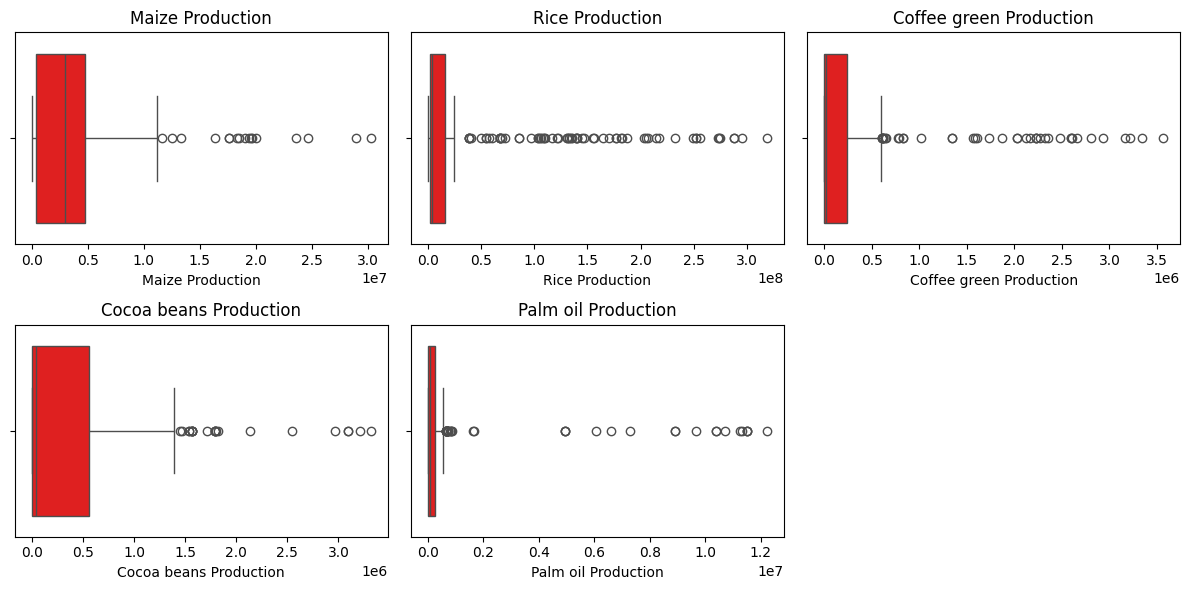

In [11]:
commodities = df_filtered.columns[2:]

plt.figure(figsize=(12, 6))

for i, commodity in enumerate(commodities, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_filtered[commodity], color='red')
    plt.title(commodity)

plt.tight_layout()
plt.show()

## Data Preprocessing

### Handling Outliers

Transformasi log diterapkan untuk mengurangi dampak nilai ekstrem dalam data produksi.

In [12]:
df_transformed = df_filtered.copy()

for col in commodities:
    df_transformed[col] = np.log1p(df_transformed[col])

df_transformed

,Entity,Year,Maize Production,Rice Production,Coffee green Production,Cocoa beans Production,Palm oil Production
5062,Indonesia,1961,14.641045,15.890682,3.872242,9.903538,9.980587
5063,Indonesia,1962,14.991979,15.978215,3.897924,10.239996,10.043380
5064,Indonesia,1963,14.673240,15.982868,3.858200,10.373522,10.118720
5065,Indonesia,1964,15.142214,16.053151,3.900153,10.463132,10.126751
5066,Indonesia,1965,14.676078,16.082988,3.901569,10.463132,10.211083
...,...,...,...,...,...,...,...
11449,Vietnam,2017,15.446664,14.733844,4.442651,14.185447,11.897916
11450,Vietnam,2018,15.399437,14.505288,4.672829,14.143912,11.897916
11451,Vietnam,2019,15.369890,14.254035,4.077537,14.201918,12.745354
11452,Vietnam,2020,15.332418,14.496192,3.218876,14.243351,15.616941


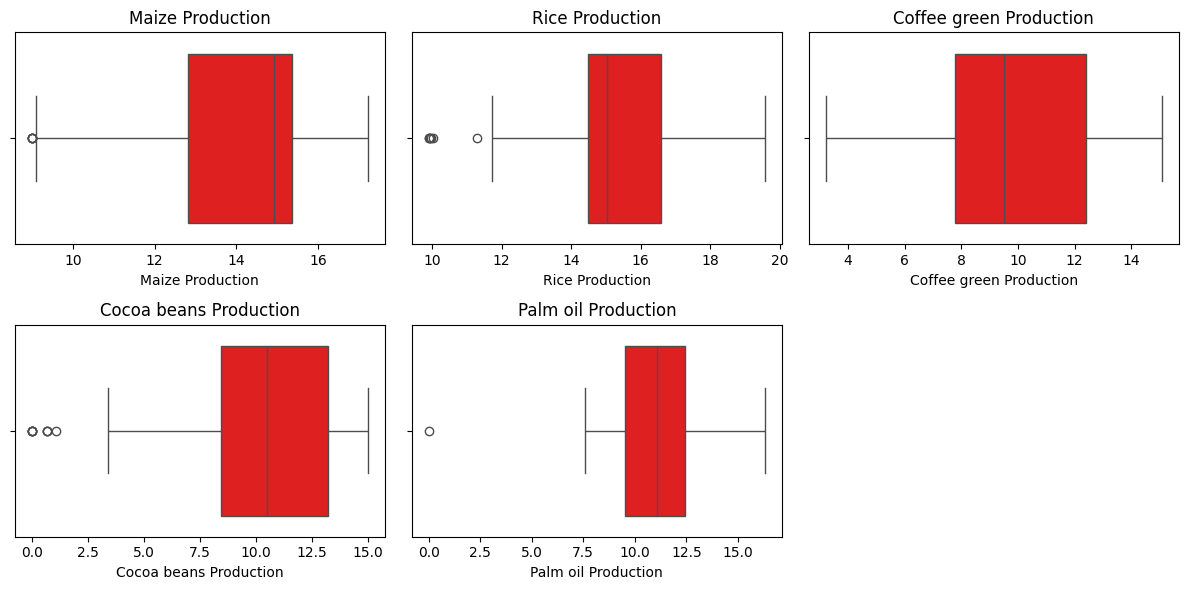

In [13]:
plt.figure(figsize=(12, 6))

for i, commodity in enumerate(commodities, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_transformed[commodity], color='red')
    plt.title(commodity)

plt.tight_layout()

### Data Normalization

In [14]:
df_normalized = df_transformed.copy()

scalers = {}

for col in commodities:
    scaler = MinMaxScaler()
    df_normalized[col] = scaler.fit_transform(df_normalized[[col]])
    scalers[col] = scaler

df_normalized

,Entity,Year,Maize Production,Rice Production,Coffee green Production,Cocoa beans Production,Palm oil Production
5062,Indonesia,1961,0.686313,0.618756,0.055055,0.659623,0.611591
5063,Indonesia,1962,0.728914,0.627802,0.057219,0.682033,0.615439
5064,Indonesia,1963,0.690222,0.628283,0.053872,0.690926,0.620056
5065,Indonesia,1964,0.747151,0.635546,0.057407,0.696895,0.620548
5066,Indonesia,1965,0.690566,0.638630,0.057526,0.696895,0.625716
...,...,...,...,...,...,...,...
11449,Vietnam,2017,0.784109,0.499200,0.103120,0.944819,0.729082
11450,Vietnam,2018,0.778376,0.475579,0.122516,0.942052,0.729082
11451,Vietnam,2019,0.774789,0.449613,0.072354,0.945916,0.781011
11452,Vietnam,2020,0.770240,0.474639,0.000000,0.948675,0.956976


## Data Splitting

In [15]:
target_countries = ['Indonesia', 'Vietnam', 'Thailand', 'Philippines', 'Malaysia']
commodities = ['Maize Production', 'Rice Production', 'Coffee green Production',
               'Cocoa beans Production', 'Palm oil Production']

df_splits = {}

for country in target_countries:
    for commodity in commodities:
        key = f"{country} - {commodity}"

        df_sub = df_normalized[
            df_normalized['Entity'] == country][[
                    'Year', commodity]].dropna().reset_index(drop=True)
        if len(df_sub) > 10:
            split_idx = int(len(df_sub) * 0.8)
            train =df_sub[commodity].iloc[:split_idx].values
            test = df_sub[commodity].iloc[split_idx:].values
            test_years = df_sub['Year'].iloc[split_idx + 5:].values

            df_splits[key] = {
                'train': train,
                'test': test,
                'years_test': test_years,
                'total_years': len(df_sub)
            }

summary = pd.DataFrame([
    {
        'Country – Commodity': key,
        'Train Length': len(val['train']),
        'Test Length': len(val['test']),
        'Total Years': val['total_years']
    }
    for key, val in df_splits.items()
])

summary

,Country – Commodity,Train Length,Test Length,Total Years
0,Indonesia - Maize Production,48,13,61
1,Indonesia - Rice Production,48,13,61
2,Indonesia - Coffee green Production,48,13,61
3,Indonesia - Cocoa beans Production,48,13,61
4,Indonesia - Palm oil Production,48,13,61
5,Vietnam - Maize Production,48,13,61
6,Vietnam - Rice Production,48,13,61
7,Vietnam - Coffee green Production,48,13,61
8,Vietnam - Cocoa beans Production,48,13,61
9,Vietnam - Palm oil Production,48,13,61


## Data Reshape

In [16]:
look_back = 5

def create_sequences(series, look_back=5):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i+look_back])
        y.append(series[i+look_back])
    return np.array(X), np.array(y)

reshaped_data = {}

for key, split in df_splits.items():
    train = split['train']
    test = split['test']

    X_train, y_train = create_sequences(train, look_back)
    X_test, y_test = create_sequences(test, look_back)

    X_train = X_train.reshape((X_train.shape[0], look_back, 1))
    X_test = X_test.reshape((X_test.shape[0], look_back, 1))

    reshaped_data[key] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'years_test': split['years_test']
    }

print("Available pairs in reshaped_data:")

for key in reshaped_data.keys():
    print("-", key)

Available pairs in reshaped_data:
- Indonesia - Maize Production
- Indonesia - Rice Production
- Indonesia - Coffee green Production
- Indonesia - Cocoa beans Production
- Indonesia - Palm oil Production
- Vietnam - Maize Production
- Vietnam - Rice Production
- Vietnam - Coffee green Production
- Vietnam - Cocoa beans Production
- Vietnam - Palm oil Production
- Thailand - Maize Production
- Thailand - Rice Production
- Thailand - Coffee green Production
- Thailand - Cocoa beans Production
- Thailand - Palm oil Production
- Philippines - Maize Production
- Philippines - Rice Production
- Philippines - Coffee green Production
- Philippines - Cocoa beans Production
- Philippines - Palm oil Production
- Malaysia - Maize Production
- Malaysia - Rice Production
- Malaysia - Coffee green Production
- Malaysia - Cocoa beans Production
- Malaysia - Palm oil Production


Check one to inspect from reshaped_data

In [17]:
key = 'Indonesia - Maize Production'

print(f"Data for {key}:\n")
print("X_train shape:", reshaped_data[key]['X_train'].shape)
print("y_train shape:", reshaped_data[key]['y_train'].shape)
print("X_test shape:", reshaped_data[key]['X_test'].shape)
print("y_test shape:", reshaped_data[key]['y_test'].shape)
print("years_test shape:", reshaped_data[key]['years_test'].shape)

Data for Indonesia - Maize Production:

X_train shape: (43, 5, 1)
y_train shape: (43,)
X_test shape: (8, 5, 1)
y_test shape: (8,)
years_test shape: (8,)


## Modelling and Testing

### Modelling

In [18]:
def train_lstm_model(X_train, y_train, X_test, y_test, look_back=5, epochs=100):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        mode='min',
        min_delta=0.001,
        verbose=1
    )

    model.fit(
        X_train, y_train,
        epochs=epochs,
        verbose=1,
        callbacks=[early_stop]
    )

    y_pred = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5

    return model, y_pred, mse, rmse

In [19]:
model_results = {}

for key in reshaped_data.keys():
    print(f"\nTraining for {key}")
    data = reshaped_data[key]
    model, y_pred, mse, rmse = train_lstm_model(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        look_back=5, epochs=100
    )
    model_results[key] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'y_pred': y_pred
    }


Training for Indonesia - Maize Production


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.6401
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.5953
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5667
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.5234 
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4891
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4482
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4100
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3792
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3470 
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3173
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.2862
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2590 
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2288
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.2010
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1732 
Epoch 16/100
2/

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 621ms/step - loss: 0.5982
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5448
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5124
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4607
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4115
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3732
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3304
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2942
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2594
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2246
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1858
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1593
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1258
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0973
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0733
Epoch 16/100
2/2 ━━━━━━━━━━━━━

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 619ms/step - loss: 0.2098
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1853
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1890
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1773
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1700
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1507
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1406
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1304
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1220
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1039
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0966
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0887
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0822
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0728
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0756
Epoch 16/100
2/2 ━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 897ms/step - loss: 0.4222
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3859
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3812
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3449
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3325
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3061
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2811
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2560
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2350
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2108
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2036
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1798
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1559
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1375
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1183
Epoch 16/100
2/2 ━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 616ms/step - loss: 0.3646
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.3345
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3119
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2936
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2708
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2522
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2302
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2105
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1934
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1745
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1563
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1430
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1236
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1071
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0888
Epoch 16/100
2/2 ━━━━━━━━━━━━━

### Testing: Evaluation and Visualization

Menggunakan MSE (Mean Squared Error) dan RMSE (Root Mean Squared Error)

In [20]:
results_summary = []

for key in model_results:
    model = model_results[key]['model']
    data = reshaped_data[key]
    y_pred = model.predict(data['X_test'], verbose=0)
    y_true = data['y_test']

    commodity = key.split(" - ")[-1].strip()
    scaler = scalers[commodity]

    y_pred_inv = scaler.inverse_transform(y_pred)
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))

    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = mse ** 0.5

    results_summary.append({
        'Country – Commodity': key,
        'MSE': mse,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results_summary)
results_df

,Country – Commodity,MSE,RMSE
0,Indonesia - Maize Production,0.055567,0.235727
1,Indonesia - Rice Production,0.161616,0.402014
2,Indonesia - Coffee green Production,0.085410,0.292250
3,Indonesia - Cocoa beans Production,0.678937,0.823976
4,Indonesia - Palm oil Production,0.548538,0.740633
5,Vietnam - Maize Production,0.006338,0.079610
6,Vietnam - Rice Production,0.023238,0.152442
7,Vietnam - Coffee green Production,4.115817,2.028748
8,Vietnam - Cocoa beans Production,1.260445,1.122695
9,Vietnam - Palm oil Production,8.816613,2.969278


Insight:

1. Model paling presisi:
  - Filipina – jagung (RMSE 0.037)
  - Indonesia – beras (RMSE 0.189)

2. Model paling meleset:
  - Malaysia – kakao (RMSE 2.936)
  - Vietnam – sawit (RMSE 2.682)
  - Filipina – beras (RMSE 2.805)

Prediksi sawit dan kakao cenderung sulit untuk semua negara.

#### Plot Testing and Training

In [21]:
scaler_key = key.split(" - ")[-1].strip()
scaler = scalers[scaler_key]

y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(data['y_test'].reshape(-1, 1))

In [22]:
def plot_forecast_with_years_original(key, model, data_dict, scalers, save=False):
    data = data_dict[key]
    commodity = key.split("-")[-1].strip()
    scaler = scalers[commodity]

    y_train_pred = model.predict(data['X_train'], verbose=0)
    y_test_pred = model.predict(data['X_test'], verbose=0)

    y_train_actual = scaler.inverse_transform(data['y_train'].reshape(-1, 1)).flatten()
    y_train_pred_actual = scaler.inverse_transform(y_train_pred).flatten()

    y_test_actual = scaler.inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
    y_test_pred_actual = scaler.inverse_transform(y_test_pred).flatten()

    years_test = data['years_test'][:len(y_test_actual)]
    start_year = years_test[0] - len(y_train_actual)
    years_train = list(range(start_year, years_test[0]))

    plt.figure(figsize=(14, 5))

    # Training
    plt.subplot(1, 2, 1)
    plt.plot(years_train, y_train_actual, label='Actual Train')
    plt.plot(years_train, y_train_pred_actual, '--', label='Predicted Train')
    plt.title(f'Training – {key}')
    plt.xlabel('Year'); plt.ylabel('Production (tonnes)')
    plt.xticks(rotation=45); plt.legend(); plt.grid(True)

    # Testing
    plt.subplot(1, 2, 2)
    plt.plot(years_test, y_test_actual, label='Actual Test')
    plt.plot(years_test, y_test_pred_actual, '--', label='Predicted Test')
    plt.title(f'Testing – {key}')
    plt.xlabel('Year'); plt.ylabel('Production (tonnes)')
    plt.xticks(rotation=45); plt.legend(); plt.grid(True)

    plt.tight_layout()
    if save:
        safe_key = key.replace(" ", "_").replace(",", "").replace("–", "-")
        plt.savefig(f"{safe_key}.png")
    plt.show()

Visualizing forecast for Indonesia - Maize Production


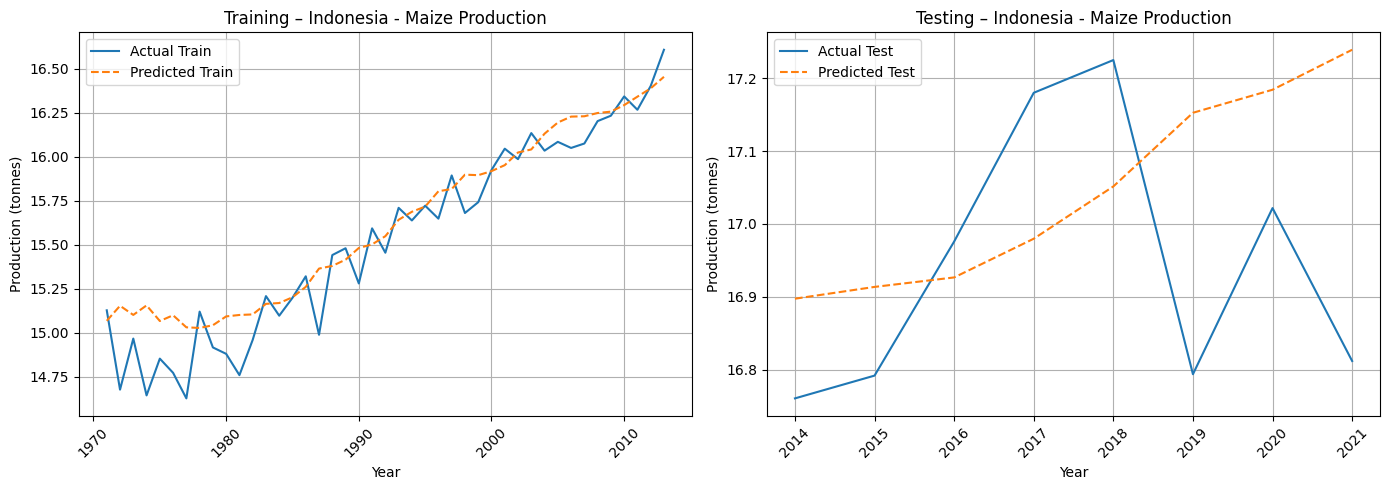

Visualizing forecast for Indonesia - Rice Production


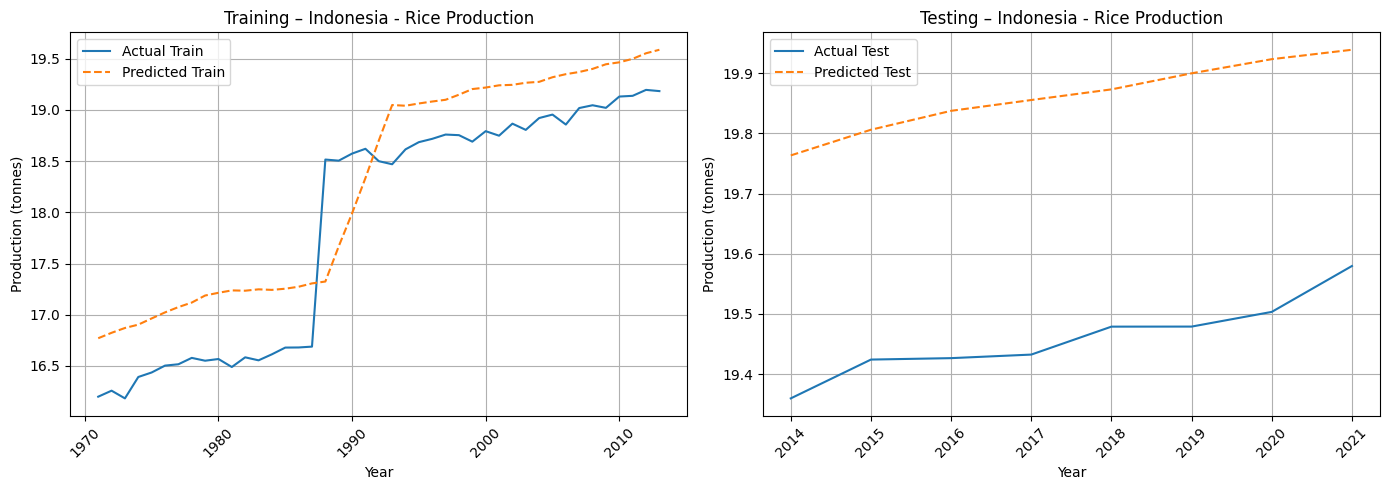

Visualizing forecast for Indonesia - Coffee green Production


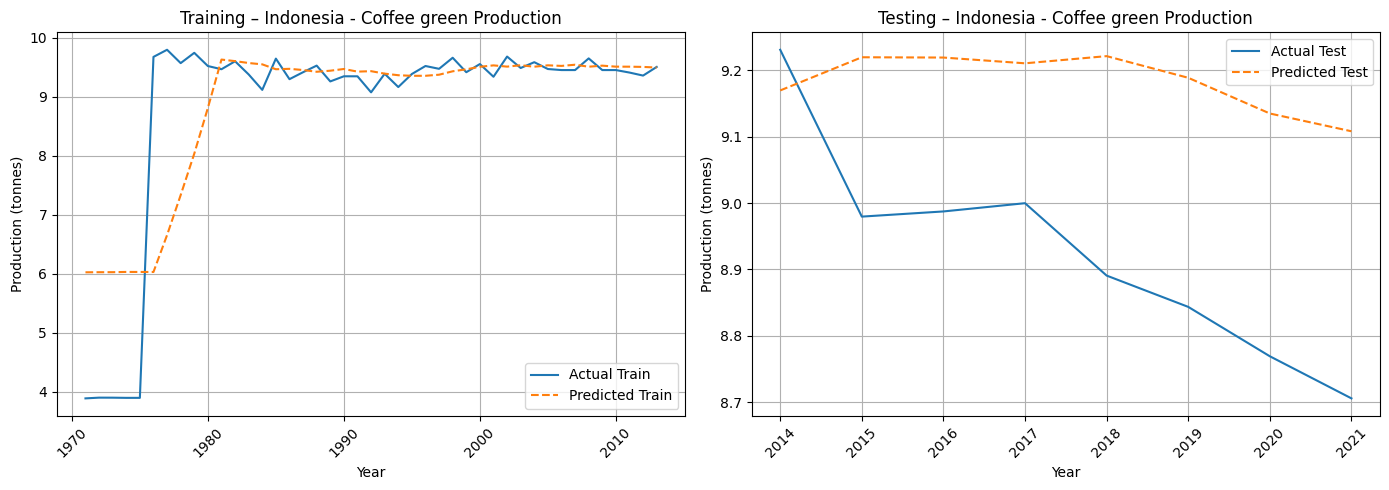

Visualizing forecast for Indonesia - Cocoa beans Production


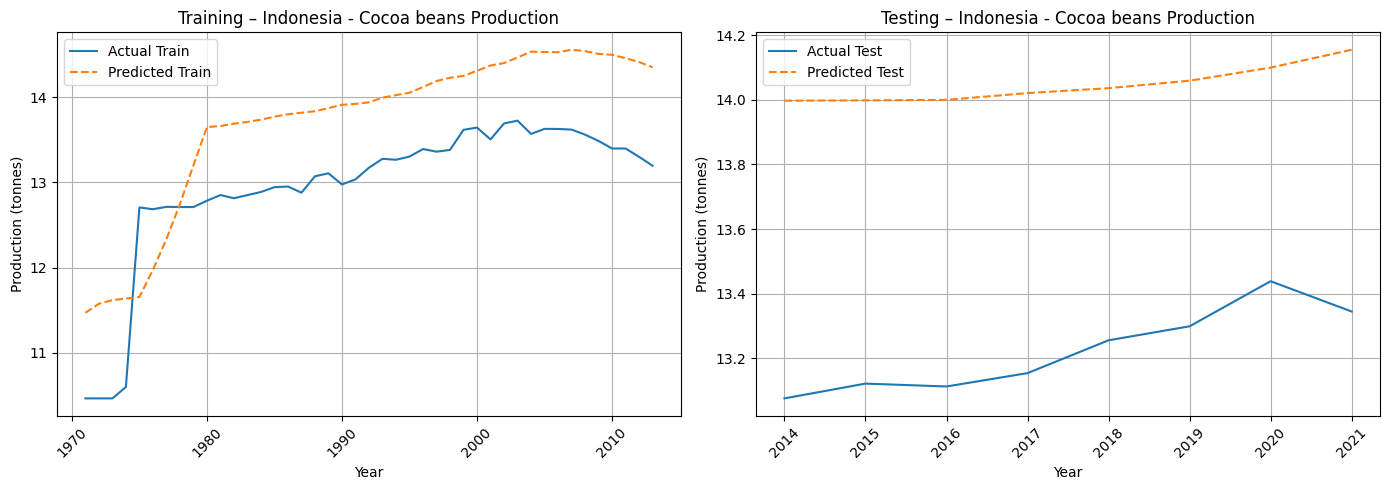

Visualizing forecast for Indonesia - Palm oil Production


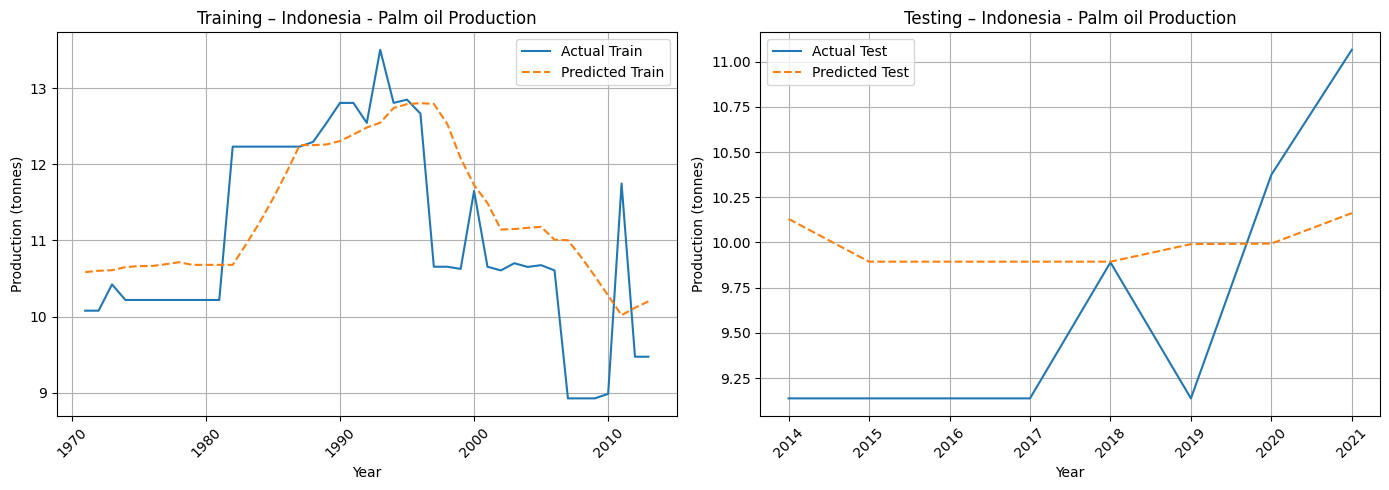

Visualizing forecast for Vietnam - Maize Production


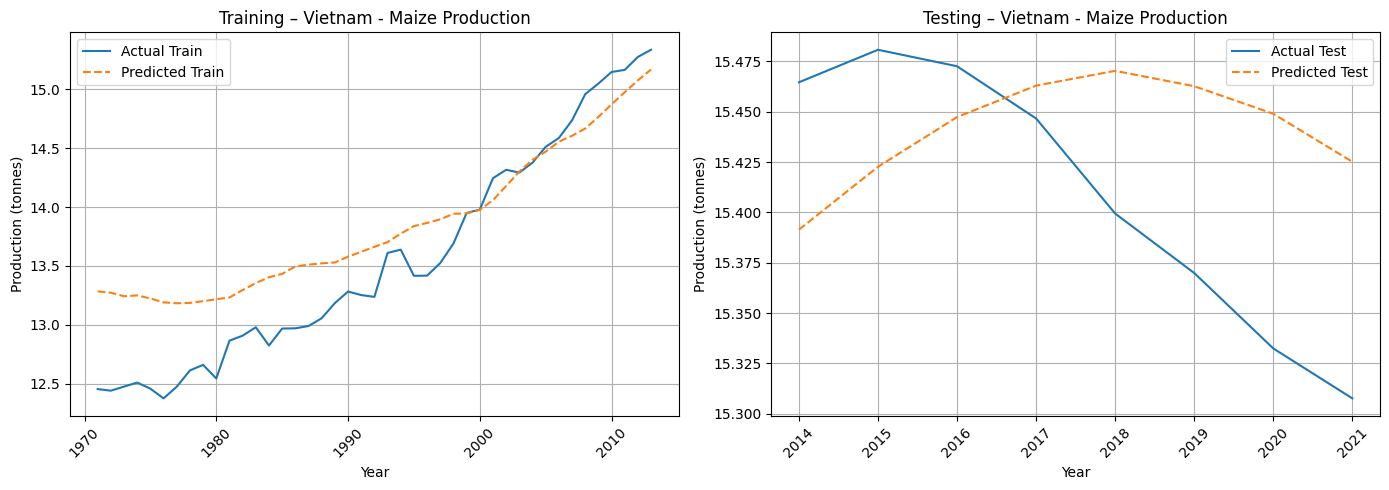

Visualizing forecast for Vietnam - Rice Production


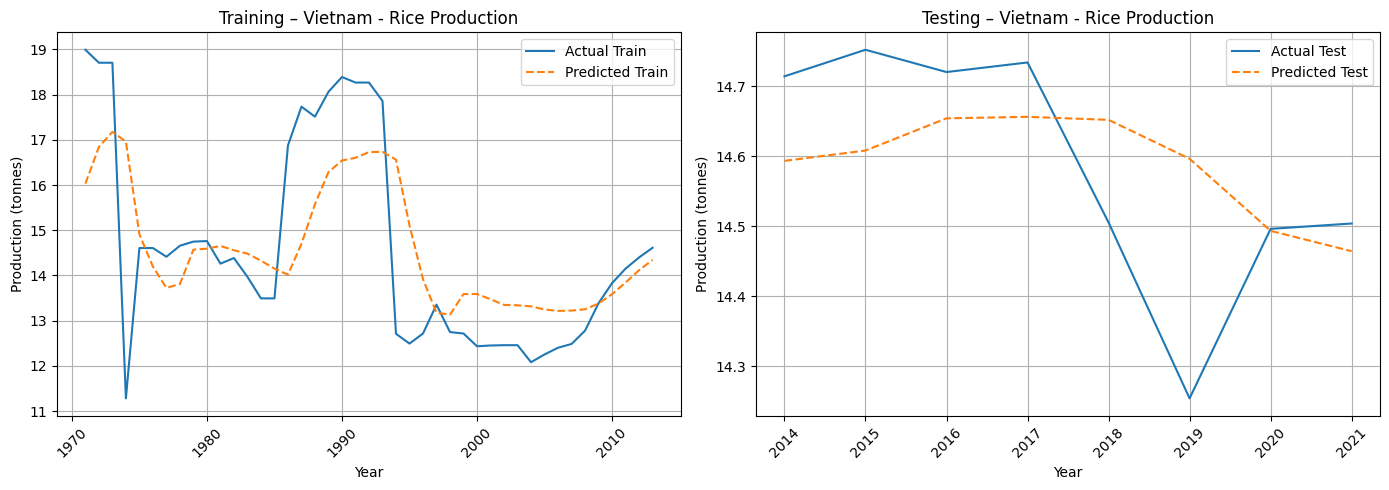

Visualizing forecast for Vietnam - Coffee green Production


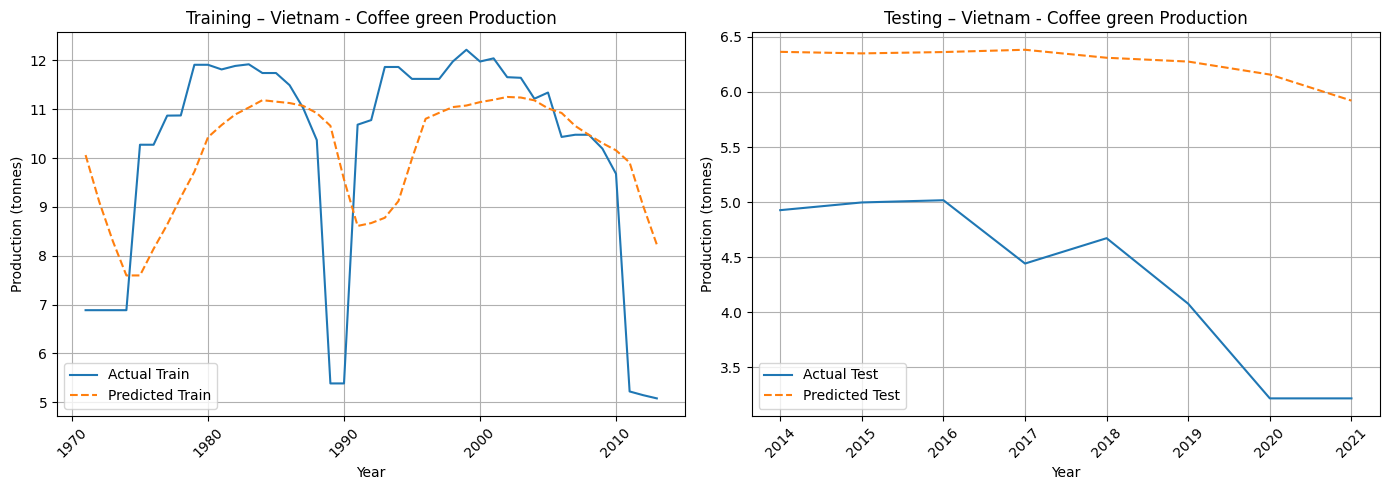

Visualizing forecast for Vietnam - Cocoa beans Production


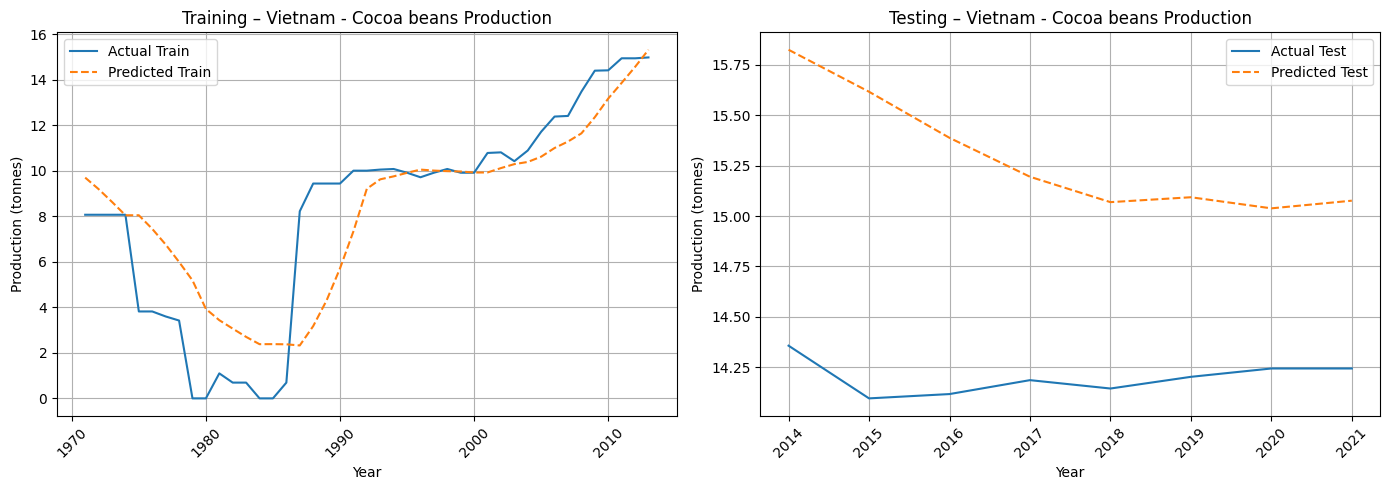

Visualizing forecast for Vietnam - Palm oil Production


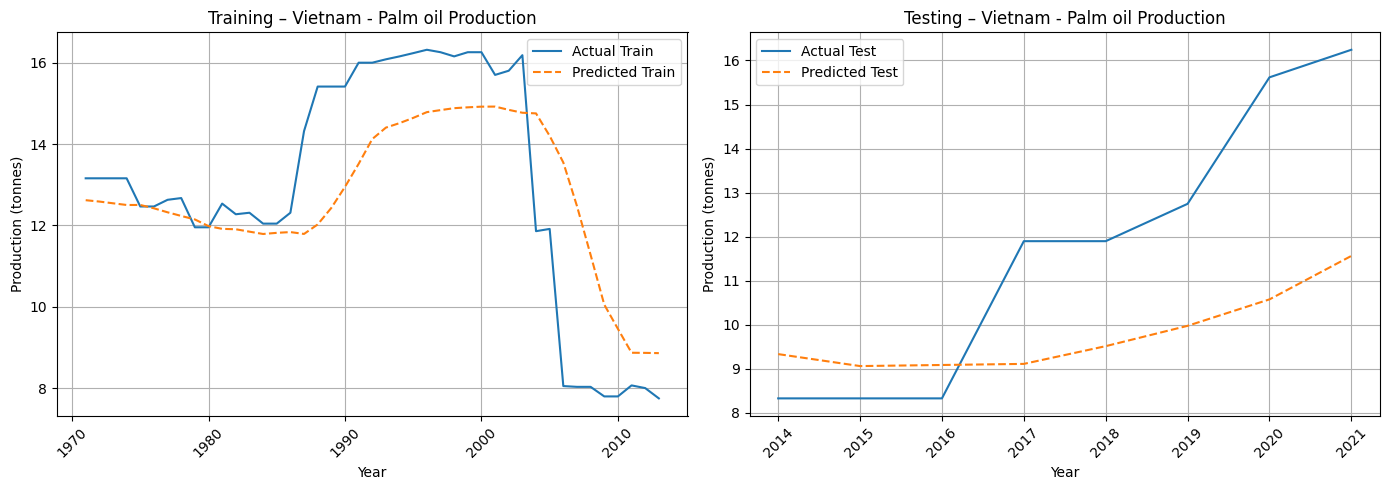

Visualizing forecast for Thailand - Maize Production


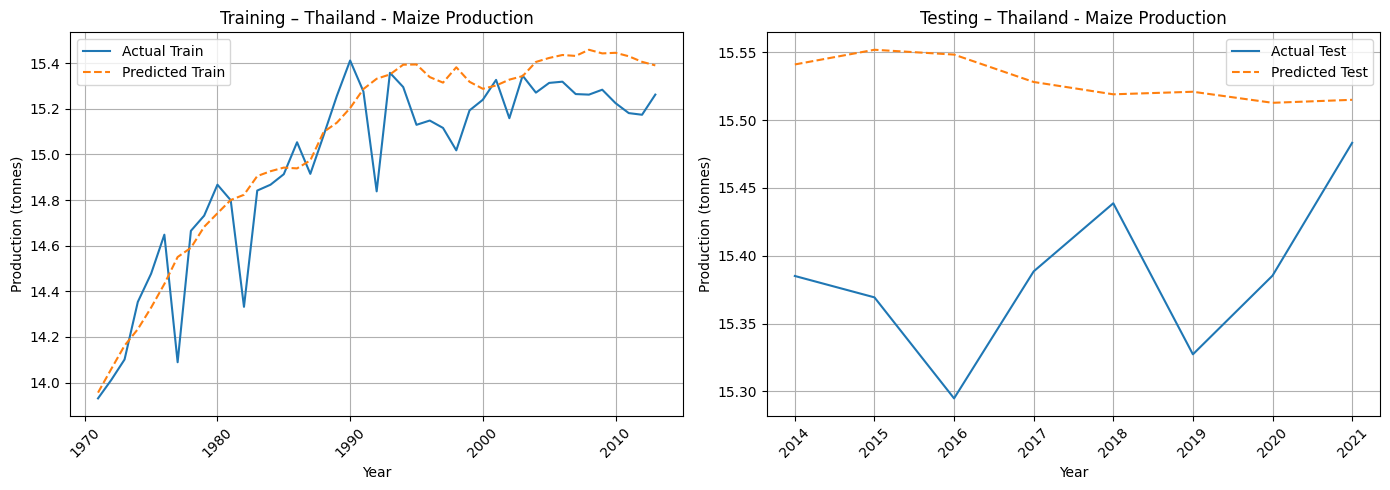

Visualizing forecast for Thailand - Rice Production


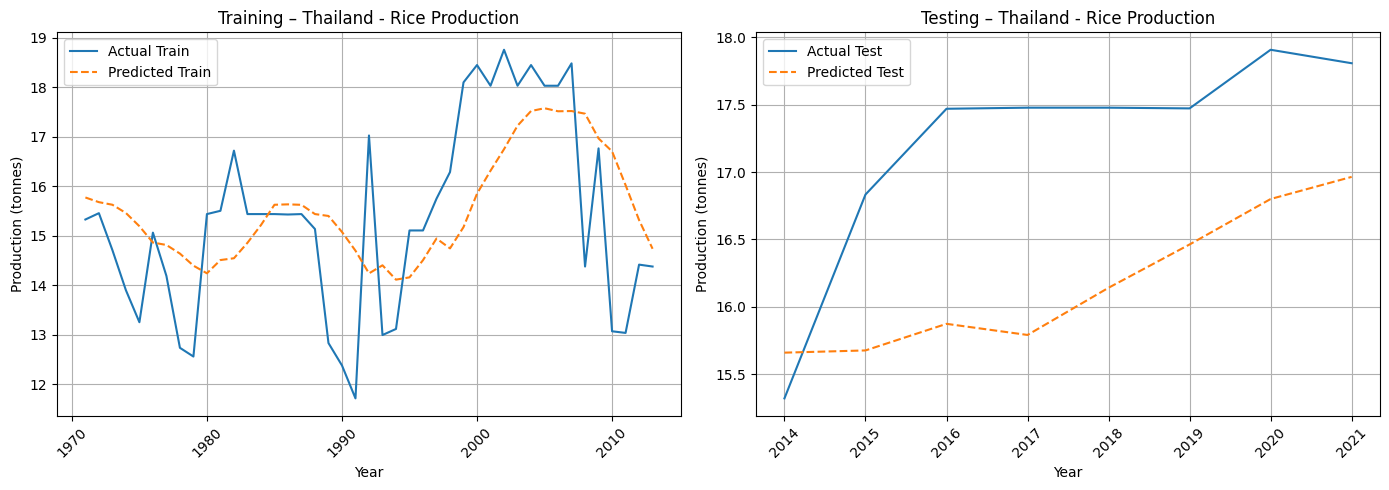

Visualizing forecast for Thailand - Coffee green Production


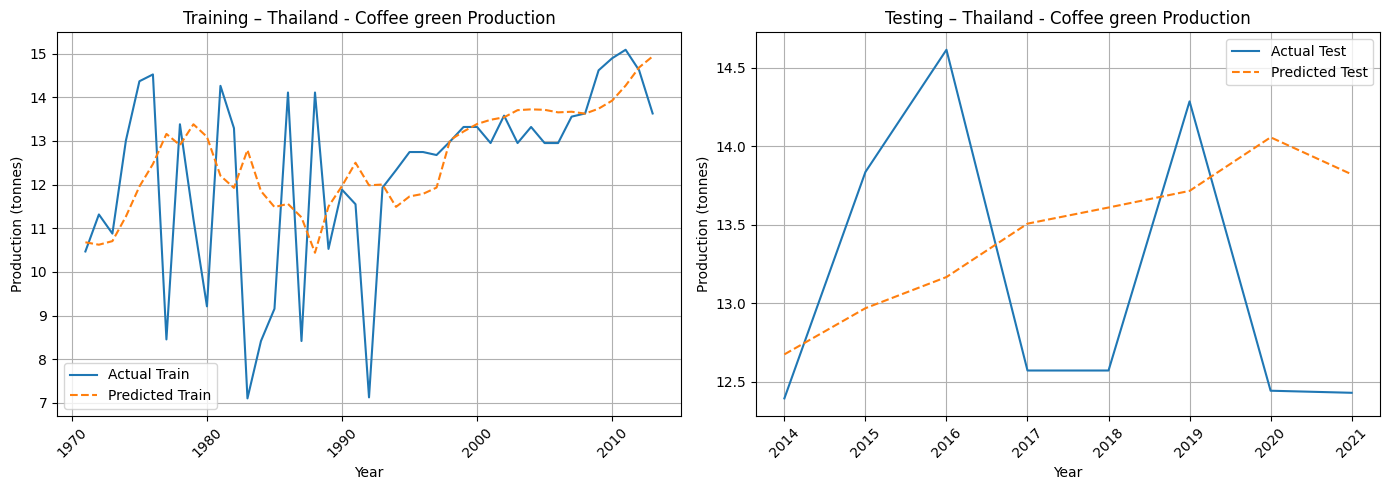

Visualizing forecast for Thailand - Cocoa beans Production


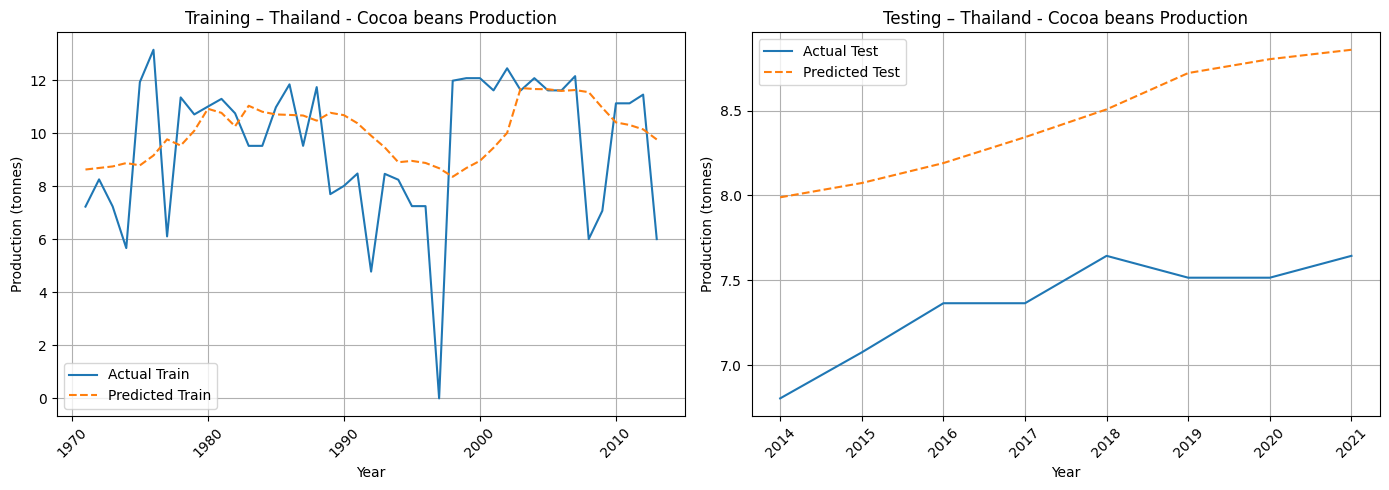

Visualizing forecast for Thailand - Palm oil Production


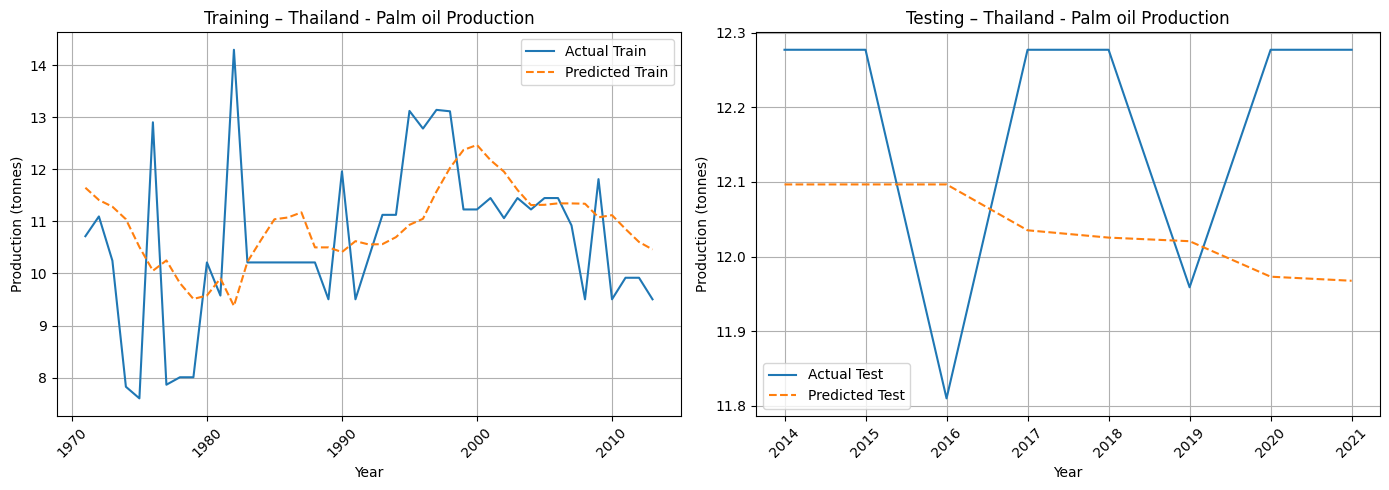

Visualizing forecast for Philippines - Maize Production


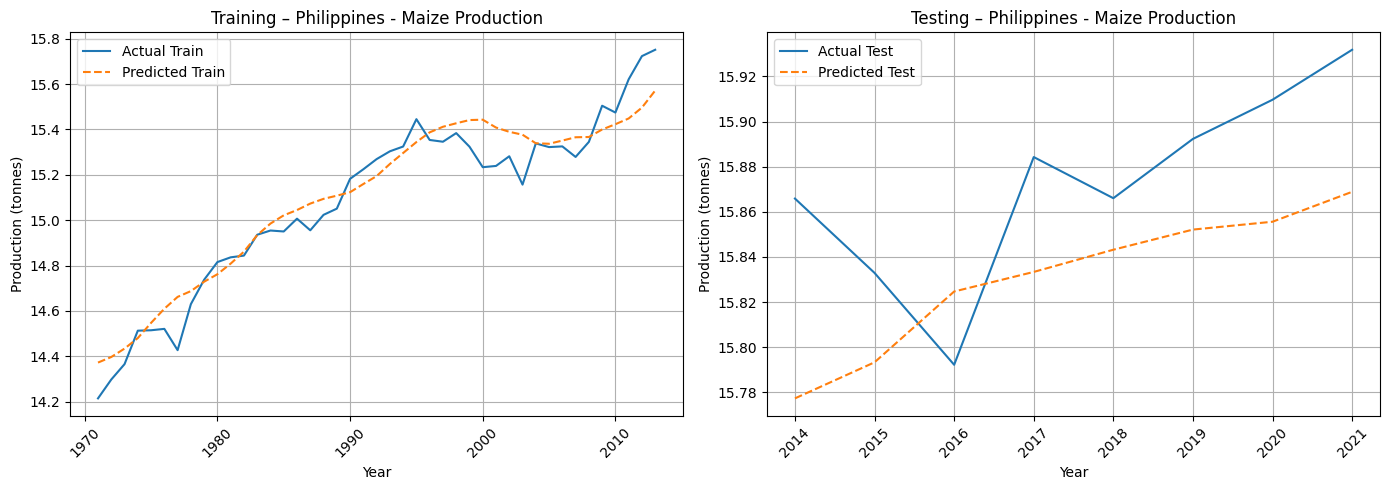

Visualizing forecast for Philippines - Rice Production


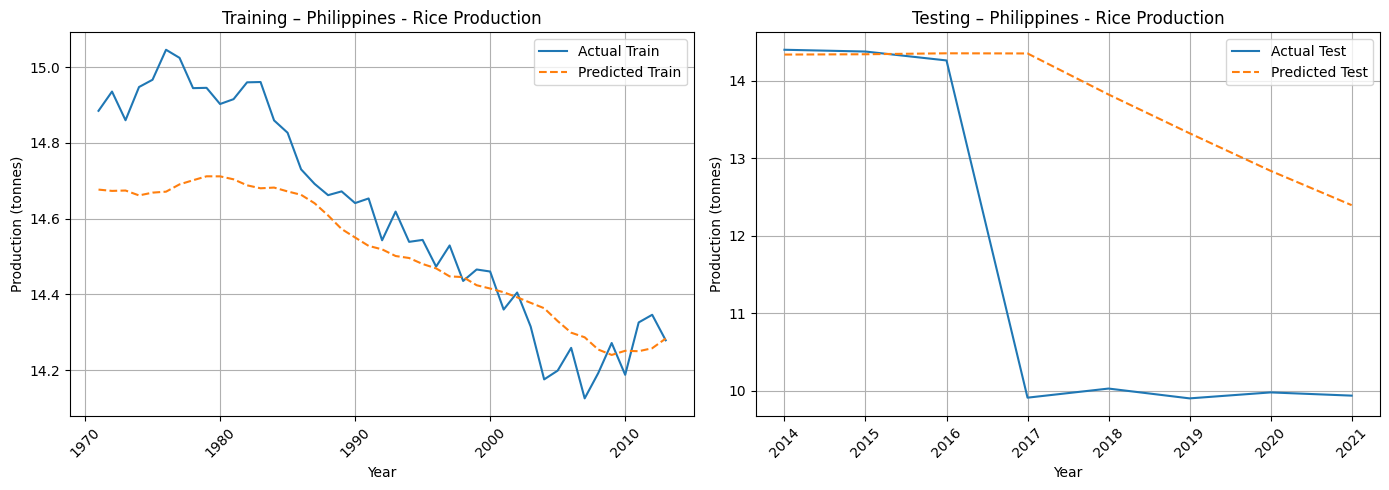

Visualizing forecast for Philippines - Coffee green Production


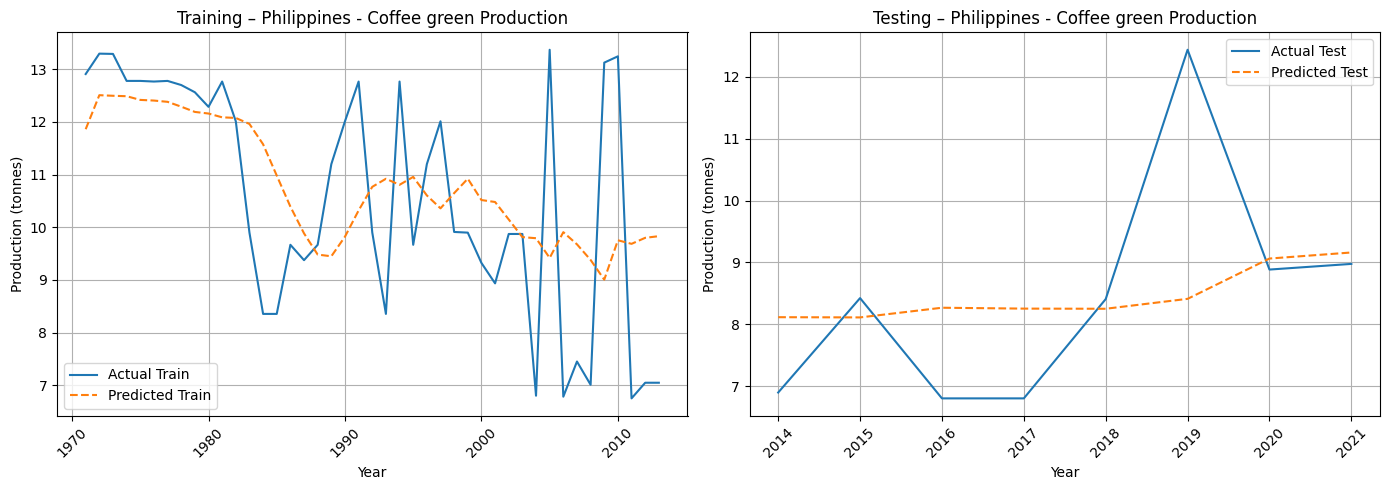

Visualizing forecast for Philippines - Cocoa beans Production


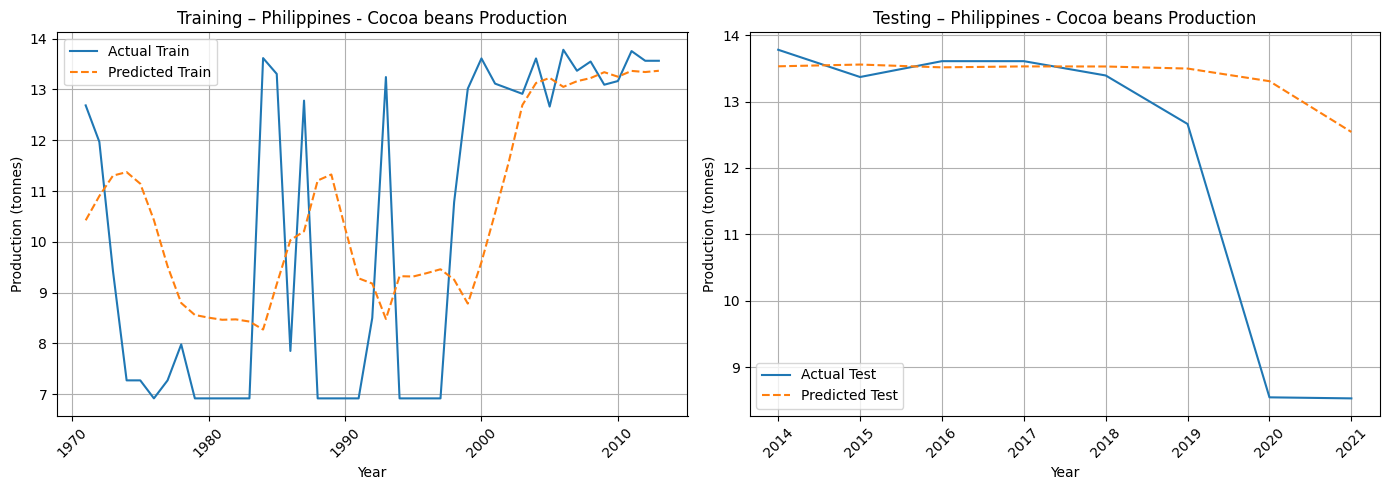

Visualizing forecast for Philippines - Palm oil Production


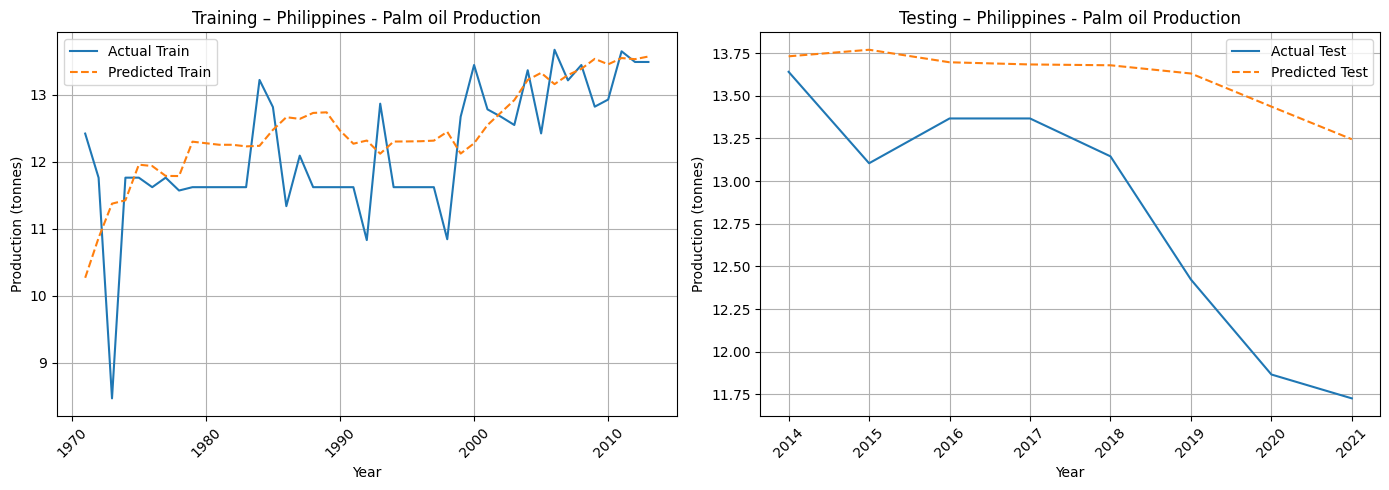

Visualizing forecast for Malaysia - Maize Production


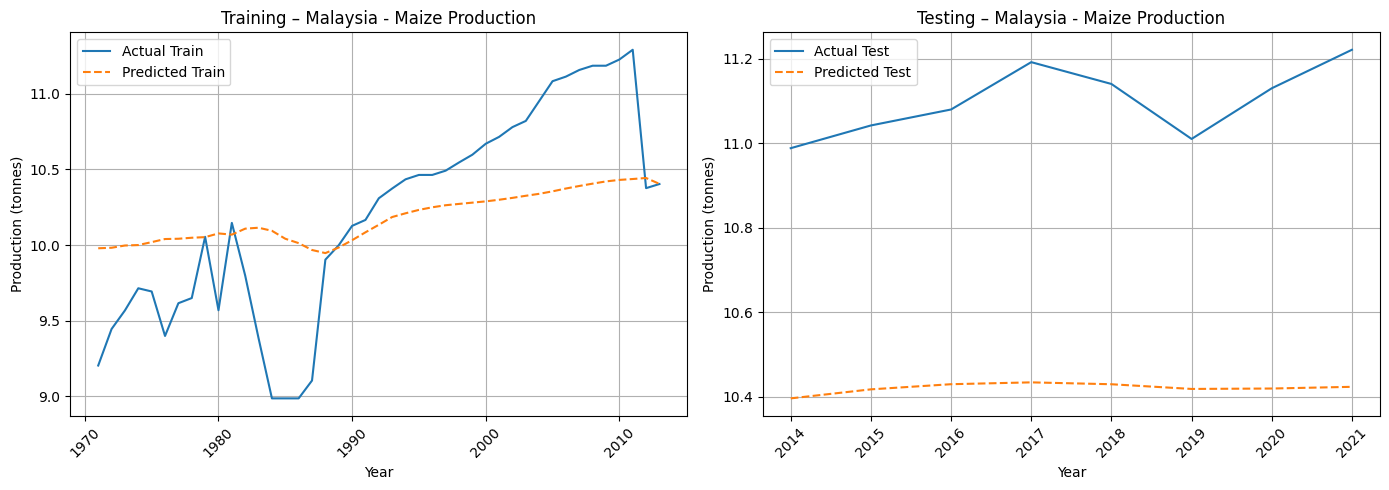

Visualizing forecast for Malaysia - Rice Production


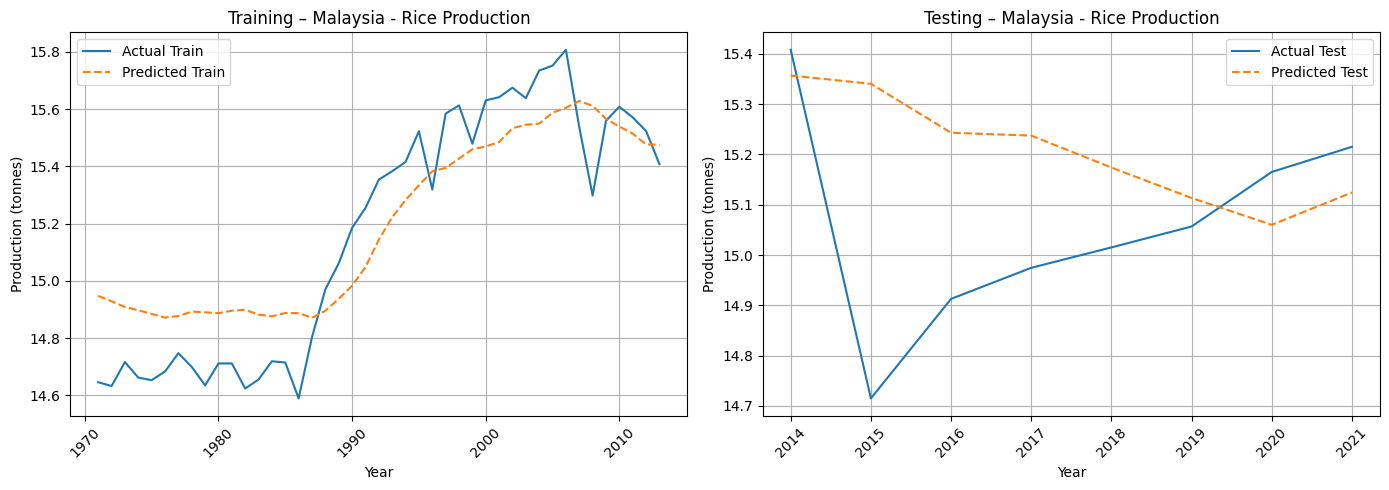

Visualizing forecast for Malaysia - Coffee green Production


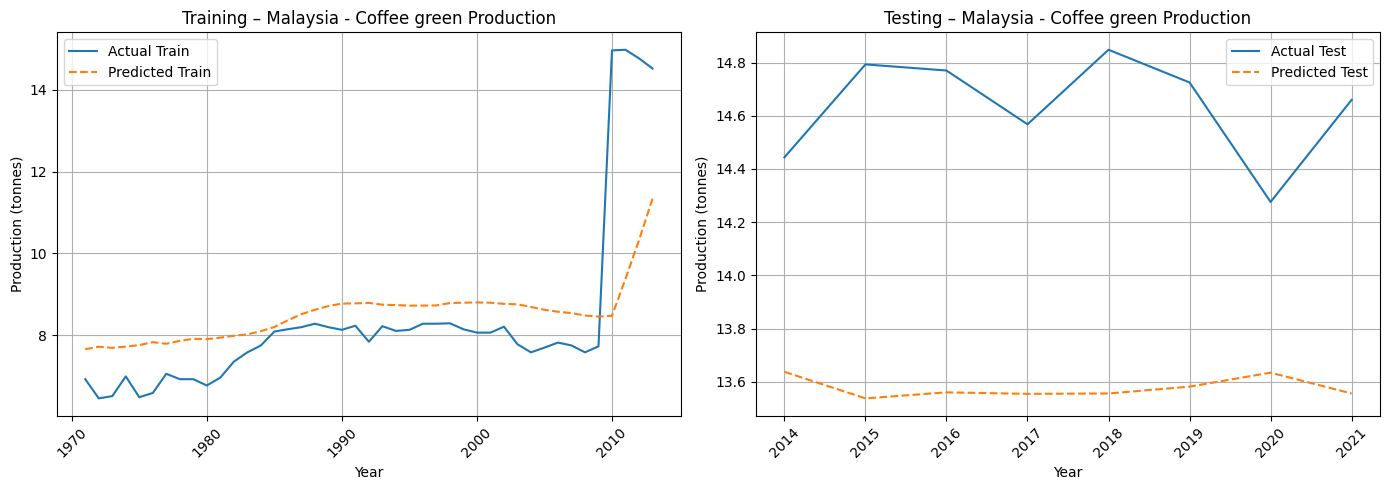

Visualizing forecast for Malaysia - Cocoa beans Production


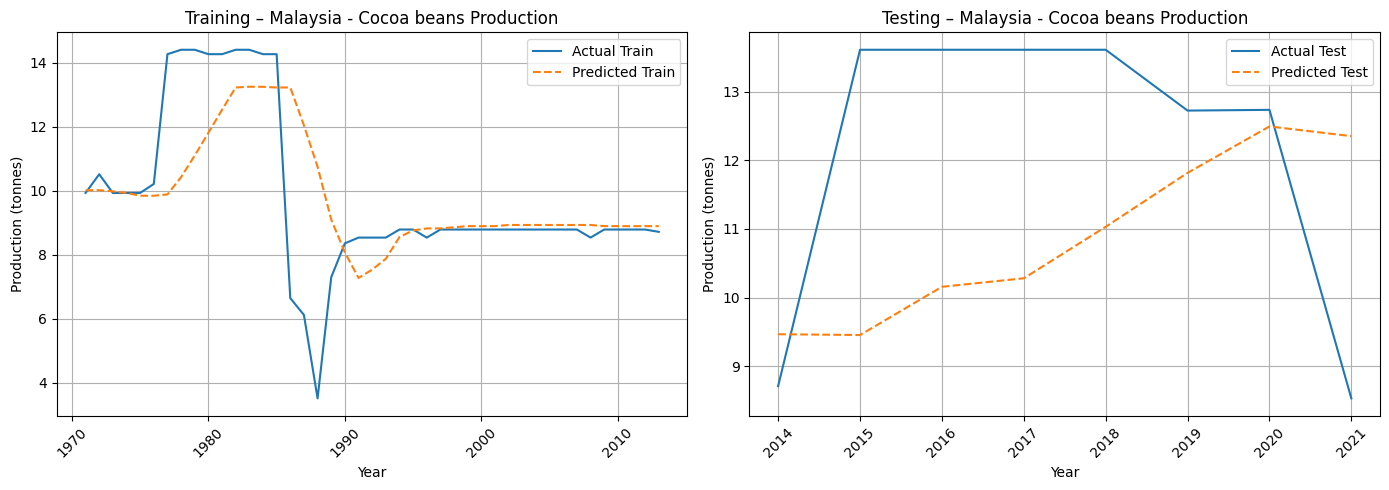

Visualizing forecast for Malaysia - Palm oil Production


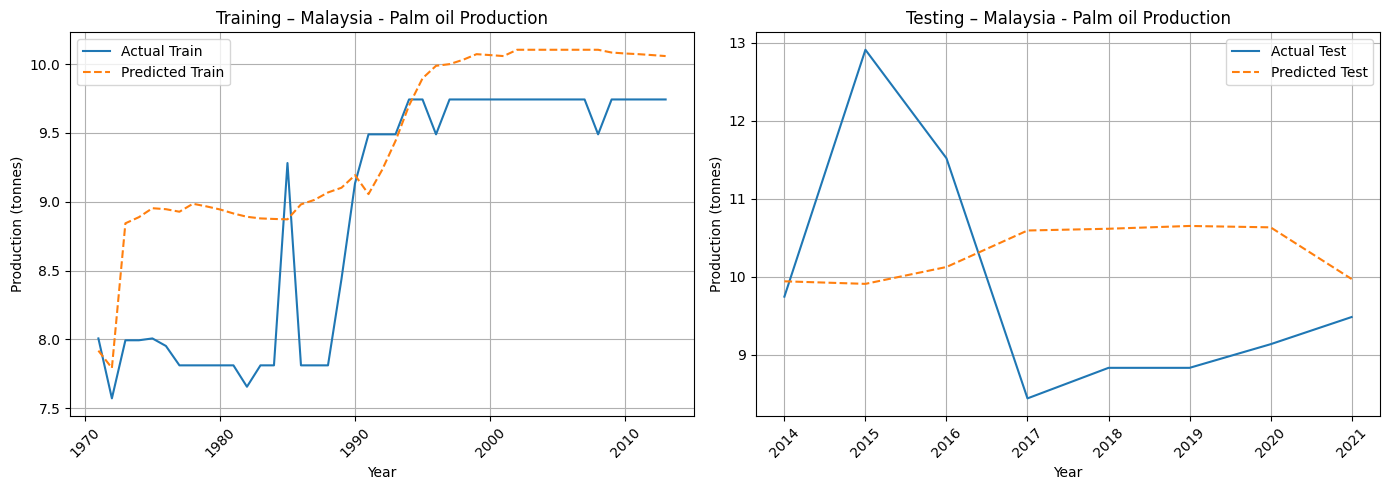

In [23]:
for key in model_results:
    print(f"Visualizing forecast for {key}")
    plot_forecast_with_years_original(
        key=key,
        model=model_results[key]['model'],
        data_dict=reshaped_data,
        scalers=scalers,
    )

## Future Prediction

In [24]:
forecast_results = []

look_back = 5
target_year = 2030

for key in model_results:
    model = model_results[key]['model']
    data = reshaped_data[key]
    scaler = scalers[key.split("-")[-1].strip()]
    commodity = key.split("-")[-1].strip()
    country = key.split("-")[0].strip()

    last_sequence = np.concatenate([data['y_train'], data['y_test']])[-look_back:]
    years_last_known = data['years_test'][-1]
    years_to_forecast = target_year - years_last_known

    current_sequence = last_sequence.copy()
    preds_scaled = []

    for _ in range(years_to_forecast):
        input_seq = current_sequence[-look_back:].reshape((1, look_back, 1))
        next_pred = model.predict(input_seq, verbose=0)
        preds_scaled.append(next_pred[0, 0])
        current_sequence = np.append(current_sequence, next_pred[0, 0])

    # Inverse transform to original scale
    preds_actual = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

    forecast_results.append({
        'Country': country,
        'Commodity': commodity,
        'Forecast2030': preds_actual[-1],
        'FromYear': years_last_known + 1,
        'ToYear': target_year
    })

forecast_df = pd.DataFrame(forecast_results)
forecast_df.sort_values(by=['Commodity', 'Forecast2030'], ascending=[True, False])

,Country,Commodity,Forecast2030,FromYear,ToYear
8,Vietnam,Cocoa beans Production,18.852167,2022,2030
3,Indonesia,Cocoa beans Production,16.272663,2022,2030
18,Philippines,Cocoa beans Production,11.395243,2022,2030
13,Thailand,Cocoa beans Production,10.179720,2022,2030
23,Malaysia,Cocoa beans Production,10.057014,2022,2030
12,Thailand,Coffee green Production,14.344359,2022,2030
22,Malaysia,Coffee green Production,11.759093,2022,2030
17,Philippines,Coffee green Production,10.026734,2022,2030
2,Indonesia,Coffee green Production,9.317180,2022,2030
7,Vietnam,Coffee green Production,7.756784,2022,2030


### Forecasted Production in 2030 by Commodity (Indonesia vs Others)

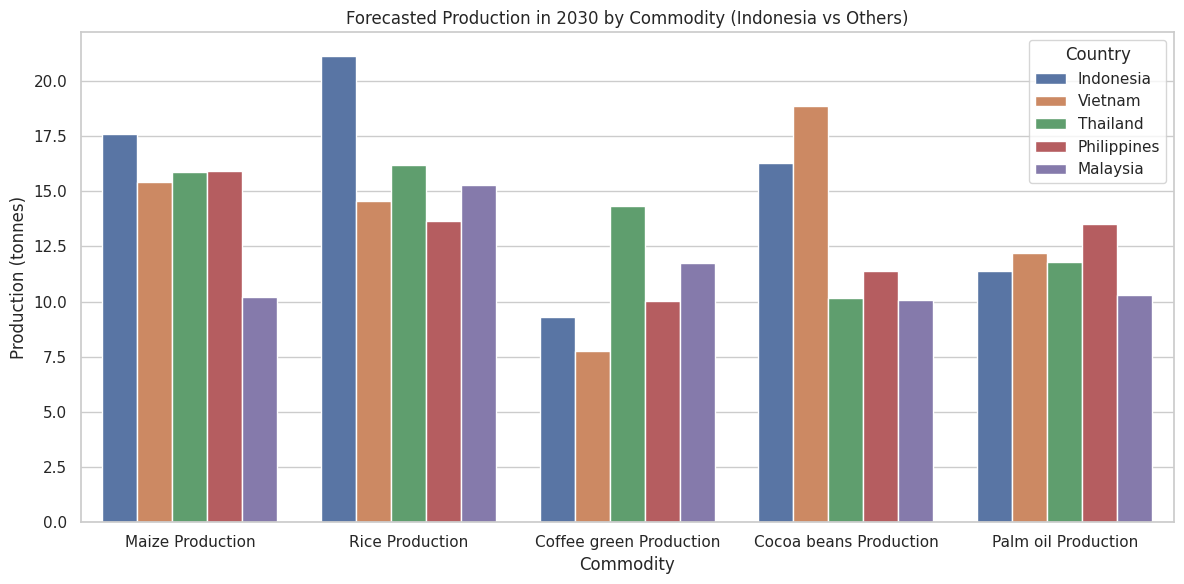

In [25]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(data=forecast_df, x='Commodity', y='Forecast2030', hue='Country')

plt.title('Forecasted Production in 2030 by Commodity (Indonesia vs Others)')
plt.ylabel('Production (tonnes)')
plt.xlabel('Commodity')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [26]:
def forecast_future(model, last_sequence, n_years, scaler, look_back=5):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(n_years):
        input_seq = current_sequence[-look_back:].reshape((1, look_back, 1))
        next_pred = model.predict(input_seq, verbose=0)
        predictions.append(next_pred[0, 0])
        current_sequence = np.append(current_sequence, next_pred[0, 0])

    # Inverse transform
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    return predictions

In [27]:
forecast_by_commodity = {}

for key in model_results:
    model = model_results[key]['model']
    data = reshaped_data[key]
    scaler = scalers[key.split("-")[-1].strip()]
    commodity = key.split("-")[-1].strip()
    country = key.split("-")[0].strip()

    last_sequence = np.concatenate([data['y_train'], data['y_test']])[-5:]
    years_last_known = data['years_test'][-1]
    years_to_forecast = 2030 - years_last_known
    forecast_years = list(range(years_last_known + 1, 2031))

    preds = forecast_future(model, last_sequence, years_to_forecast, scaler)

    if commodity not in forecast_by_commodity:
        forecast_by_commodity[commodity] = {}

    forecast_by_commodity[commodity][country] = {
        'years': forecast_years,
        'predictions': preds
    }

### Forecast per Commodity

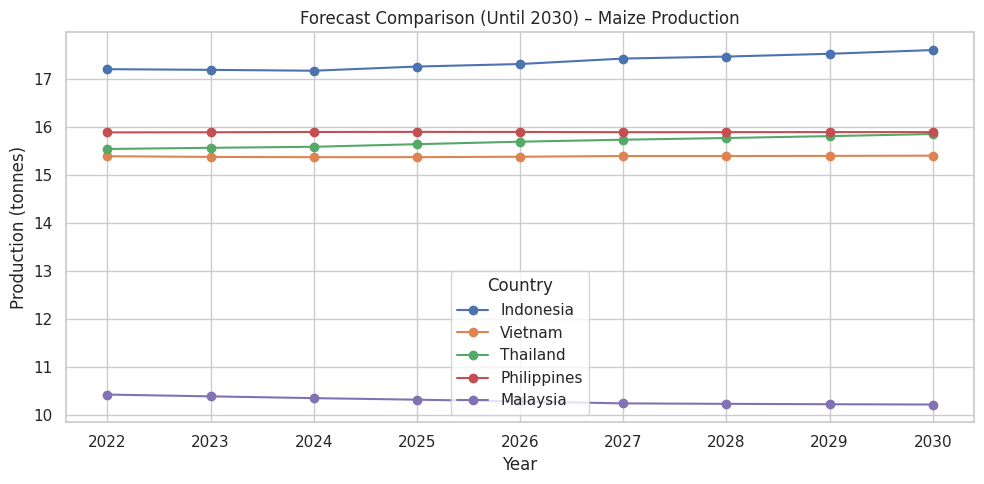

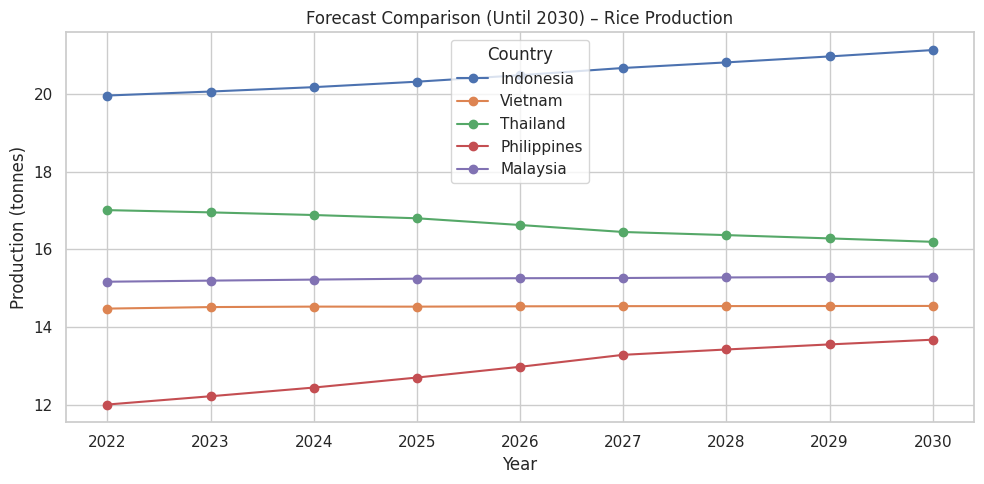

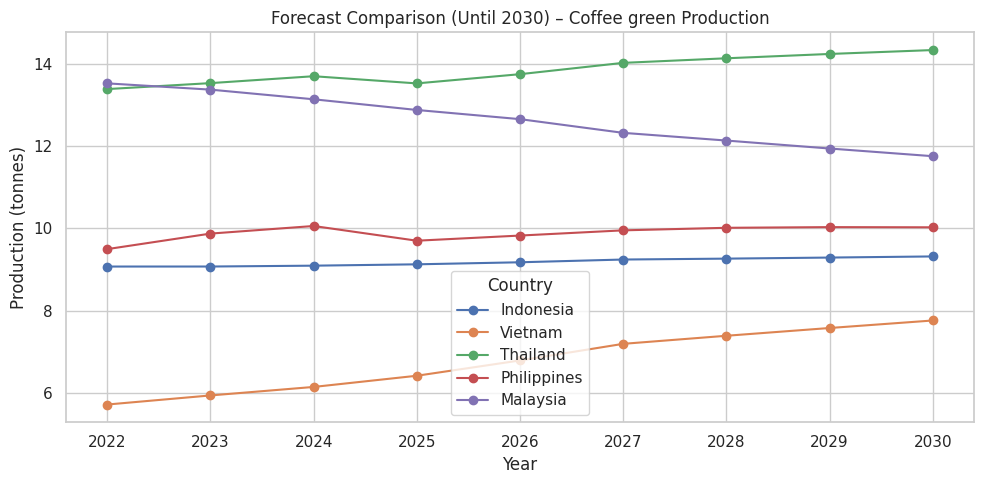

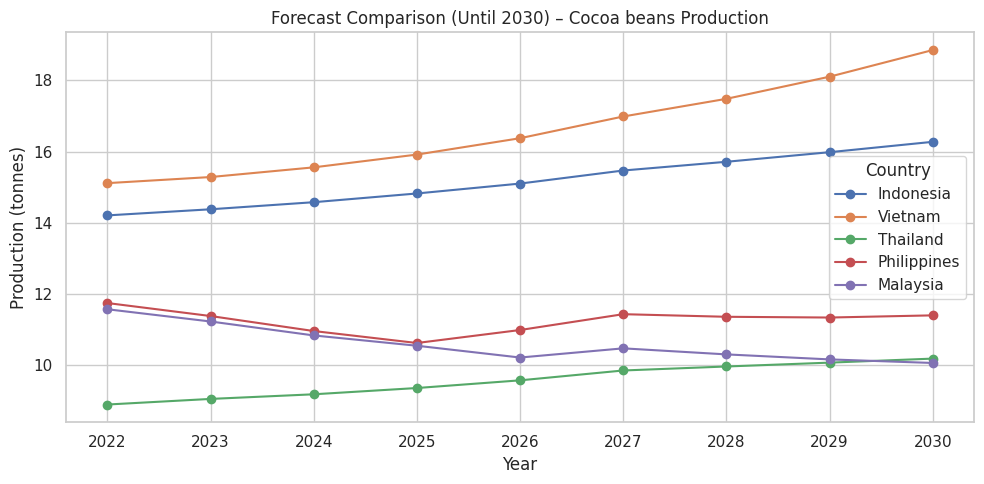

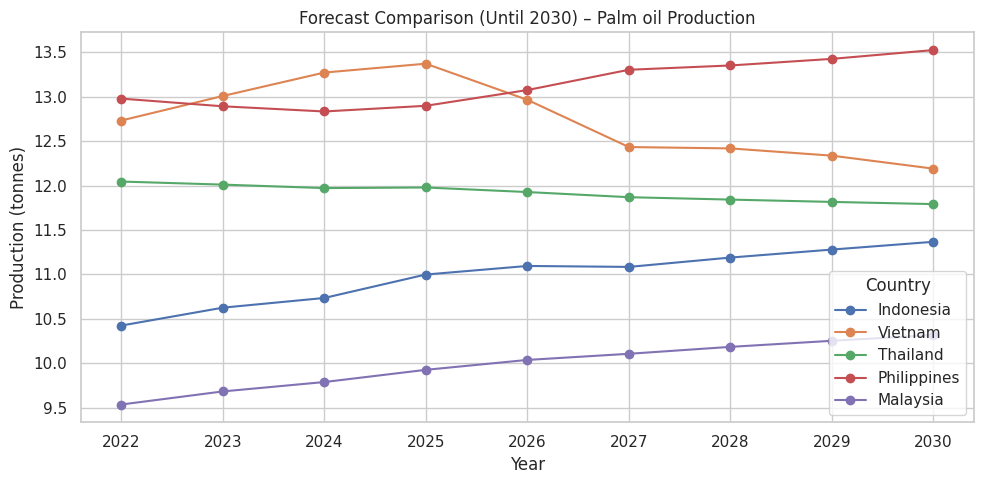

In [28]:
for commodity, countries_data in forecast_by_commodity.items():
    plt.figure(figsize=(10, 5))
    for country, values in countries_data.items():
        plt.plot(values['years'], values['predictions'], marker='o', label=country)

    plt.title(f'Forecast Comparison (Until 2030) – {commodity}')
    plt.xlabel('Year'); plt.ylabel('Production (tonnes)')
    plt.grid(True); plt.legend(title='Country')
    plt.tight_layout()
    plt.show()